In [110]:
import os 
import sys
from pathlib import Path
%pwd

'E:\\PROJECT\\TimeSeries'

In [111]:
os.chdir(Path("E:\PROJECT\TimeSeries"))

In [112]:
%pwd

'E:\\PROJECT\\TimeSeries'

In [113]:
import pandas as pd
import numpy as np

main_df = pd.read_csv("data/train.csv")
main_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [114]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [115]:
main_df.isna().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [116]:
main_df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [117]:
main_df.dropna(inplace=True)
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [118]:
main_df.shape

(3000888, 6)

In [119]:
main_df["sales"].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

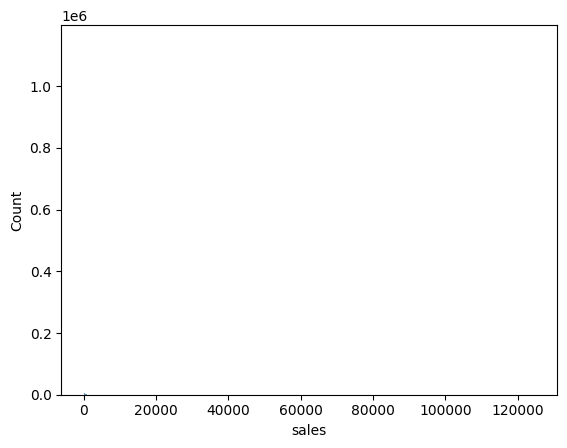

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(x = "sales" , data = main_df)
plt.show()

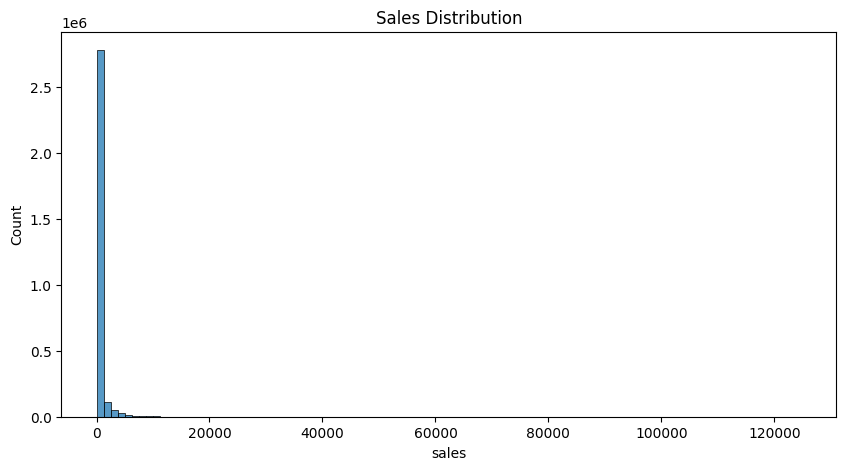

In [121]:
plt.figure(figsize=(10,5))
sns.histplot(main_df["sales"], bins=100)
plt.title("Sales Distribution")
plt.show()

In [122]:
main_df.tail()

,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [123]:
main_df["date"] = pd.to_datetime(main_df["date"])
main_df.tail()

,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [124]:
main_df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [125]:
main_df.reset_index(drop=True, inplace=True)
main_df.tail()

,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [126]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


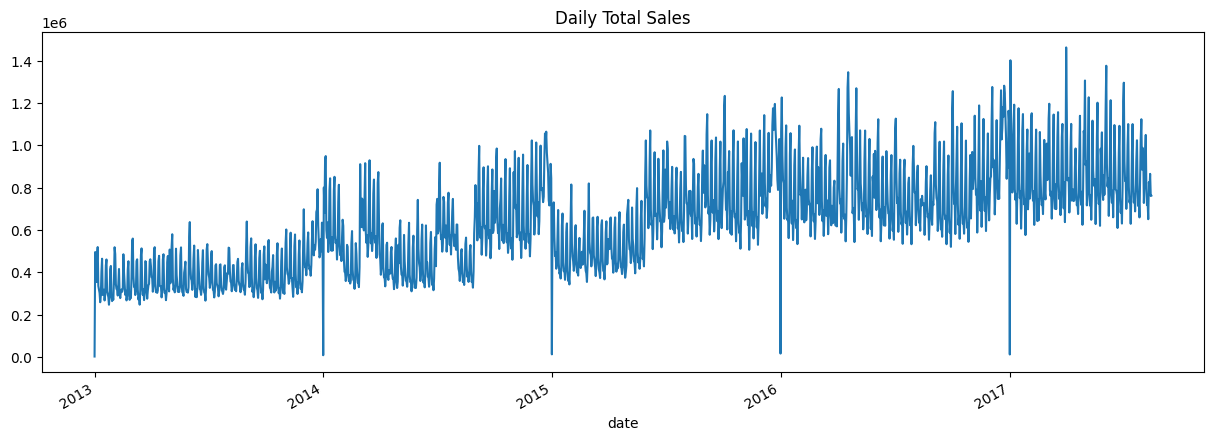

In [127]:
daily_sales = main_df.groupby("date")["sales"].sum()

plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title("Daily Total Sales")
plt.show()

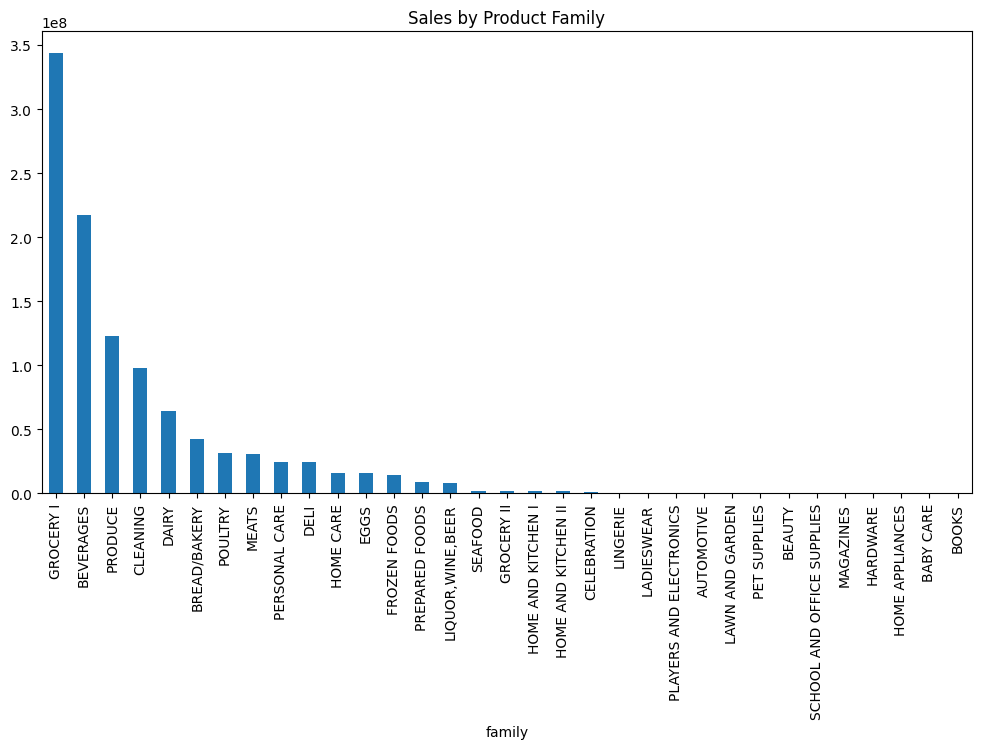

In [128]:
family_sales = (
    main_df.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
family_sales.plot(kind="bar")
plt.title("Sales by Product Family")
plt.show()

In [129]:
promo_impact = main_df.groupby(
    "onpromotion"
)["sales"].mean()

promo_impact.head(20)

onpromotion
0      158.246681
1      467.556532
2      662.925632
3      871.408092
4      969.916135
5     1010.659835
6     1022.854287
7     1022.567058
8     1174.757003
9     1258.733993
10    1303.985479
11    1264.356349
12    1218.066159
13    1322.552007
14    1376.628033
15    1446.988239
16    1498.333841
17    1559.588638
18    1526.680412
19    1619.292366
Name: sales, dtype: float64

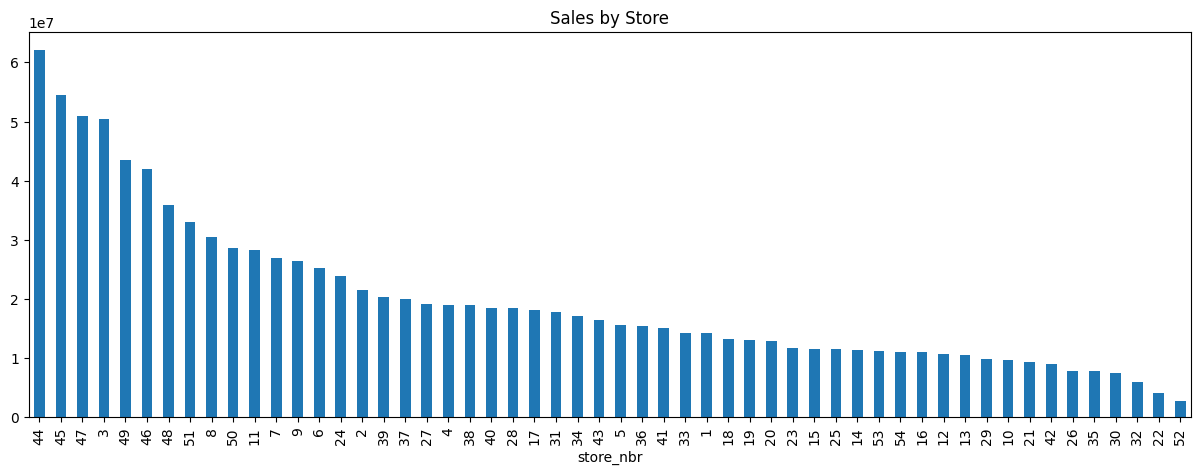

In [130]:
store_sales = (
    main_df.groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(15,5))
store_sales.plot(kind="bar")
plt.title("Sales by Store")
plt.show()

In [131]:
transactions_df = pd.read_csv("data/transactions.csv")
stores_df = pd.read_csv("data/stores.csv")
holidays_df = pd.read_csv("data/holidays_events.csv")
oil_df = pd.read_csv("data/oil.csv")
test_df = pd.read_csv("data/test.csv")

In [132]:
for data in [main_df,transactions_df,stores_df,holidays_df,oil_df,test_df]:
    print()
    print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     ---

In [133]:
for data in [transactions_df,stores_df,holidays_df,oil_df,test_df]:
    if "date" in data.columns:
        data["date"] = pd.to_datetime(data["date"])

In [134]:
for data in [main_df,transactions_df,stores_df,holidays_df,oil_df,test_df]:
    print()
    print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column

In [135]:
main_df = main_df.merge(
    transactions_df,
    on=["date", "store_nbr"],
    how="left"
)

main_df.head()

,id,date,store_nbr,family,sales,onpromotion,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN


In [136]:
transactions_df.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [137]:
main_df = main_df.merge(
    stores_df,
    on="store_nbr",
    how="left"
)

main_df.head()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,Quito,Pichincha,D,13


In [138]:
main_df.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0,Quito,Pichincha,B,6
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0,Quito,Pichincha,B,6
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0,Quito,Pichincha,B,6
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0,Quito,Pichincha,B,6
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0,2155.0,Quito,Pichincha,B,6


In [139]:
main_df = main_df.merge(
    holidays_df,
    on="date",
    how="left"
)

In [140]:
holidays_df.tail()

,date,type,locale,locale_name,description,transferred
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False
349,2017-12-26,Additional,National,Ecuador,Navidad+1,False


In [141]:
main_df.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type_x,cluster,type_y,locale,locale_name,description,transferred
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054347,3000887,2017-08-15,9,SEAFOOD,16.000,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False


In [142]:
main_df.rename(columns={"type_y" : "holiday_type"},inplace=True)

In [143]:
main_df = main_df.merge(
    oil_df,
    on="date",
    how="left"
)

main_df.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type_x,cluster,holiday_type,locale,locale_name,description,transferred,dcoilwtico
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054347,3000887,2017-08-15,9,SEAFOOD,16.000,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57


In [144]:
oil_df.tail()

,date,dcoilwtico
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96
1217,2017-08-31,47.26


In [145]:
main_df.rename(columns={"type_x" : "store_type"},inplace=True)

In [146]:
main_df.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,store_type,cluster,holiday_type,locale,locale_name,description,transferred,dcoilwtico
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57
3054347,3000887,2017-08-15,9,SEAFOOD,16.000,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57


In [147]:
holidays_df.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [148]:
main_df.isnull().sum().sort_values(ascending=False)

locale_name     2551824
locale          2551824
description     2551824
holiday_type    2551824
transferred     2551824
dcoilwtico       955152
transactions     249117
id                    0
date                  0
state                 0
city                  0
onpromotion           0
sales                 0
store_nbr             0
family                0
store_type            0
cluster               0
dtype: int64

In [149]:
main_df["is_holiday"] = (
    main_df["holiday_type"]
    .notnull()
    .astype(int)
)

main_df.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,store_type,cluster,holiday_type,locale,locale_name,description,transferred,dcoilwtico,is_holiday
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57,1
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57,1
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57,1
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57,1
3054347,3000887,2017-08-15,9,SEAFOOD,16.000,0,2155.0,Quito,Pichincha,B,6,Holiday,Local,Riobamba,Fundacion de Riobamba,False,47.57,1


In [150]:
main_df["holiday_type"] = main_df["holiday_type"].fillna("No Holiday")

In [151]:
main_df.isnull().sum().sort_values(ascending=False)

transferred     2551824
description     2551824
locale          2551824
locale_name     2551824
dcoilwtico       955152
transactions     249117
date                  0
id                    0
sales                 0
store_nbr             0
store_type            0
state                 0
city                  0
onpromotion           0
family                0
holiday_type          0
cluster               0
is_holiday            0
dtype: int64

In [152]:
main_df["dcoilwtico"] = (
    main_df["dcoilwtico"]
    .ffill()
)

In [153]:
main_df.isnull().sum().sort_values(ascending=False)

transferred     2551824
description     2551824
locale          2551824
locale_name     2551824
transactions     249117
dcoilwtico         1782
date                  0
id                    0
sales                 0
store_nbr             0
store_type            0
state                 0
city                  0
onpromotion           0
family                0
holiday_type          0
cluster               0
is_holiday            0
dtype: int64

In [154]:
main_df["transactions"] = (
    main_df["transactions"]
    .fillna(0)
)

In [155]:
main_df.isnull().sum().sort_values(ascending=False)

transferred     2551824
description     2551824
locale          2551824
locale_name     2551824
dcoilwtico         1782
id                    0
date                  0
store_nbr             0
sales                 0
family                0
store_type            0
state                 0
city                  0
transactions          0
onpromotion           0
holiday_type          0
cluster               0
is_holiday            0
dtype: int64

In [156]:
main_df["dcoilwtico"] = (
    main_df["dcoilwtico"]
    .bfill()
)

In [157]:
main_df.isnull().sum().sort_values(ascending=False)

transferred     2551824
description     2551824
locale          2551824
locale_name     2551824
date                  0
id                    0
store_nbr             0
family                0
sales                 0
onpromotion           0
store_type            0
state                 0
city                  0
transactions          0
cluster               0
holiday_type          0
dcoilwtico            0
is_holiday            0
dtype: int64

In [158]:
main_df["year"] = main_df["date"].dt.year
main_df["month"] = main_df["date"].dt.month
main_df["day"] = main_df["date"].dt.day
main_df["day_of_week"] = main_df["date"].dt.dayofweek
main_df["week_of_year"] = main_df["date"].dt.isocalendar().week
main_df["quarter"] = main_df["date"].dt.quarter

In [159]:
main_df.head()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,store_type,...,description,transferred,dcoilwtico,is_holiday,year,month,day,day_of_week,week_of_year,quarter
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0.0,Quito,Pichincha,D,...,Primer dia del ano,False,93.14,1,2013,1,1,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,0.0,Quito,Pichincha,D,...,Primer dia del ano,False,93.14,1,2013,1,1,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,0.0,Quito,Pichincha,D,...,Primer dia del ano,False,93.14,1,2013,1,1,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,0.0,Quito,Pichincha,D,...,Primer dia del ano,False,93.14,1,2013,1,1,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,0.0,Quito,Pichincha,D,...,Primer dia del ano,False,93.14,1,2013,1,1,1,1,1


In [160]:
main_df.isna().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
transactions          0
city                  0
state                 0
store_type            0
cluster               0
holiday_type          0
locale          2551824
locale_name     2551824
description     2551824
transferred     2551824
dcoilwtico            0
is_holiday            0
year                  0
month                 0
day                   0
day_of_week           0
week_of_year          0
quarter               0
dtype: int64

In [161]:
main_df["is_month_start"] = (
    main_df["date"]
    .dt.is_month_start
    .astype(int)
)

main_df["is_month_end"] = (
    main_df["date"]
    .dt.is_month_end
    .astype(int)
)

In [162]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 26 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   store_nbr       int64         
 3   family          object        
 4   sales           float64       
 5   onpromotion     int64         
 6   transactions    float64       
 7   city            object        
 8   state           object        
 9   store_type      object        
 10  cluster         int64         
 11  holiday_type    object        
 12  locale          object        
 13  locale_name     object        
 14  description     object        
 15  transferred     object        
 16  dcoilwtico      float64       
 17  is_holiday      int64         
 18  year            int32         
 19  month           int32         
 20  day             int32         
 21  day_of_week     int32         
 22  week_of_year    UI

In [163]:
main_df.isna().sum()

id                      0
date                    0
store_nbr               0
family                  0
sales                   0
onpromotion             0
transactions            0
city                    0
state                   0
store_type              0
cluster                 0
holiday_type            0
locale            2551824
locale_name       2551824
description       2551824
transferred       2551824
dcoilwtico              0
is_holiday              0
year                    0
month                   0
day                     0
day_of_week             0
week_of_year            0
quarter                 0
is_month_start          0
is_month_end            0
dtype: int64

In [164]:
main_df.drop(
    columns=[
        "locale",
        "locale_name",
        "description",
        "transferred"
    ],
    inplace=True
)

main_df.tail()

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,store_type,...,dcoilwtico,is_holiday,year,month,day,day_of_week,week_of_year,quarter,is_month_start,is_month_end
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0,Quito,Pichincha,B,...,47.57,1,2017,8,15,1,33,3,0,0
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0,Quito,Pichincha,B,...,47.57,1,2017,8,15,1,33,3,0,0
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0,Quito,Pichincha,B,...,47.57,1,2017,8,15,1,33,3,0,0
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0,Quito,Pichincha,B,...,47.57,1,2017,8,15,1,33,3,0,0
3054347,3000887,2017-08-15,9,SEAFOOD,16.000,0,2155.0,Quito,Pichincha,B,...,47.57,1,2017,8,15,1,33,3,0,0


In [165]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   store_nbr       int64         
 3   family          object        
 4   sales           float64       
 5   onpromotion     int64         
 6   transactions    float64       
 7   city            object        
 8   state           object        
 9   store_type      object        
 10  cluster         int64         
 11  holiday_type    object        
 12  dcoilwtico      float64       
 13  is_holiday      int64         
 14  year            int32         
 15  month           int32         
 16  day             int32         
 17  day_of_week     int32         
 18  week_of_year    UInt32        
 19  quarter         int32         
 20  is_month_start  int64         
 21  is_month_end    int64         
dtypes: UInt32(1), date

In [166]:
main_df.isna().sum()

id                0
date              0
store_nbr         0
family            0
sales             0
onpromotion       0
transactions      0
city              0
state             0
store_type        0
cluster           0
holiday_type      0
dcoilwtico        0
is_holiday        0
year              0
month             0
day               0
day_of_week       0
week_of_year      0
quarter           0
is_month_start    0
is_month_end      0
dtype: int64

In [167]:
main_df.to_csv("clean_main_dataset.csv",index = False)

In [168]:
def preprocess(data,holidays_df,oil_df,stores_df,transactions_df):
    for df in [transactions_df,stores_df,holidays_df,oil_df,data]:
        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"])
    data = data.merge(transactions_df,on=["date", "store_nbr"],how="left")
    data = data.merge(stores_df,on="store_nbr",how="left")
    data = data.merge(holidays_df,on="date",how="left")
    data.rename(columns={"type_y" : "holiday_type"},inplace=True)
    data = data.merge(oil_df,on="date",how="left")
    data.rename(columns={"type_x" : "store_type"},inplace=True)
    data["is_holiday"] = (data["holiday_type"].notnull().astype(int))
    data["holiday_type"] = data["holiday_type"].fillna("No Holiday")
    data["dcoilwtico"] = (data["dcoilwtico"].ffill())
    data["dcoilwtico"] = (data["dcoilwtico"].bfill())
    data["transactions"] = (data["transactions"].fillna(0))
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day
    data["day_of_week"] = data["date"].dt.dayofweek
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)
    data["quarter"] = data["date"].dt.quarter
    data["is_month_start"] = (data["date"].dt.is_month_start.astype(int))
    data["is_month_end"] = (data["date"].dt.is_month_end.astype(int))
    data.drop(columns=["locale","locale_name","description","transferred"],inplace=True)

    return data


    
    
    

In [169]:
"""    cat_cols = [
        "family",
        "city",
        "state",
        "store_type",
        "holiday_type"
    ]

    encoders = {}

    for col in cat_cols:

        le = LabelEncoder()

        data[col] = le.fit_transform(
            data[col]
        )

        encoders[col] = le

    return data"""

'    cat_cols = [\n        "family",\n        "city",\n        "state",\n        "store_type",\n        "holiday_type"\n    ]\n\n    encoders = {}\n\n    for col in cat_cols:\n\n        le = LabelEncoder()\n\n        data[col] = le.fit_transform(\n            data[col]\n        )\n\n        encoders[col] = le\n\n    return data'

In [170]:
test_df = preprocess(data = test_df,holidays_df=holidays_df,oil_df=oil_df,transactions_df=transactions_df,stores_df=stores_df)

In [173]:
len(test_df.columns)

21

In [174]:
len(main_df.columns)

22

In [176]:
main_df.isna().sum()

id                0
date              0
store_nbr         0
family            0
sales             0
onpromotion       0
transactions      0
city              0
state             0
store_type        0
cluster           0
holiday_type      0
dcoilwtico        0
is_holiday        0
year              0
month             0
day               0
day_of_week       0
week_of_year      0
quarter           0
is_month_start    0
is_month_end      0
dtype: int64

In [177]:
model_data = main_df.copy()

In [178]:
from sklearn.preprocessing import LabelEncoder
cat_cols = [
        "family",
        "city",
        "state",
        "store_type",
        "holiday_type"
    ]
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    model_data[col] = le.fit_transform(model_data[col])
    encoders[col] = le


In [ ]:
model_data = model_data.sort_values(
    by=["store_nbr", "family", "date"]
)

In [ ]:
model_data["sales_lag_30"] = (model_data.groupby(["store_nbr", "family"])["sales"].shift(30))

In [ ]:
model_data["rolling_mean_7"] = (model_data.groupby(["store_nbr", "family"])["sales"].transform(lambda x:x.shift(1).rolling(7).mean()))

In [ ]:
model_data["rolling_std_30"] = (model_data.groupby(["store_nbr", "family"])["sales"].transform(lambda x:x.shift(1).rolling(30).std()))

In [ ]:
model_data.dropna(inplace=True)

In [179]:
len(model_data.columns)

22

In [180]:
import joblib

joblib.dump(
    encoders,
    "label_encoders.pkl"
)

['label_encoders.pkl']

In [181]:
split_date = "2017-01-01"

train_data = model_data[
    model_data["date"] < split_date
]

valid_data = model_data[
    model_data["date"] >= split_date
]

In [182]:
X_train = train_data.drop(
    columns=["sales", "date", "id"]
)

y_train = train_data["sales"]

In [183]:
X_valid = valid_data.drop(
    columns=["sales", "date", "id"]
)

y_valid = valid_data["sales"]

In [184]:
#Base model Xgb
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [185]:
xgb_preds = xgb_model.predict(X_valid)

In [186]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

import numpy as np
mae = mean_absolute_error(y_valid,xgb_preds)
rmse = np.sqrt(mean_squared_error(y_valid,xgb_preds))
r2 = r2_score(y_valid,xgb_preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 125.16082967674195
RMSE: 358.81493117452146
R2: 0.930225418753487


In [187]:
from sklearn.metrics import mean_squared_log_error

rmsle = np.sqrt(
    mean_squared_log_error(
        y_valid,
        np.maximum(0, xgb_preds)
    )
)

print("RMSLE:", rmsle)

RMSLE: 1.5343971896865138


In [207]:
from sklearn.model_selection import RandomizedSearchCV,TimeSeriesSplit

params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}
tscv = TimeSeriesSplit(n_splits=3)
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
preds = best_model.predict(X_valid)

from sklearn.metrics import mean_squared_log_error

rmsle = np.sqrt(
    mean_squared_log_error(
        y_valid,
        np.maximum(0, preds)
    )
)

print("RMSLE:", rmsle)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
RMSLE: 1.5165642460295554


In [188]:
daily_sales = (model_data.groupby("date")["sales"].sum().reset_index())

In [189]:
daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [190]:
split_date = "2017-01-01"

train_prophet = daily_sales[
    daily_sales["date"] < split_date
]

valid_prophet = daily_sales[
    daily_sales["date"] >= split_date
]

In [191]:
prophet_train = train_prophet.rename(columns={"date": "ds","sales": "y"})

In [192]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(prophet_train)

e:\PROJECT\TimeSeries\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
14:54:17 - cmdstanpy - INFO - Chain [1] start processing
14:54:18 - cmdstanpy - INFO - Chain [1] done processing


In [193]:
future = prophet_model.make_future_dataframe(
    periods=len(valid_prophet)
)

In [194]:
forecast = prophet_model.predict(future)

In [195]:
prophet_preds = (
    forecast.tail(len(valid_prophet))["yhat"]
    .values
)

In [196]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    valid_prophet["sales"],
    prophet_preds
)

rmse = np.sqrt(
    mean_squared_error(
        valid_prophet["sales"],
        prophet_preds
    )
)

r2 = r2_score(
    valid_prophet["sales"],
    prophet_preds
)

print("Prophet MAE:", mae)
print("Prophet RMSE:", rmse)
print("Prophet R2:", r2)

Prophet MAE: 103468.26347374012
Prophet RMSE: 217415.38173528243
Prophet R2: 0.25706677106335474


In [198]:
daily_series = (
    daily_sales
    .set_index("date")["sales"]
)

In [199]:
daily_series.head()

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

In [200]:
train_arima = daily_series[
    daily_series.index < split_date
]

valid_arima = daily_series[
    daily_series.index >= split_date
]

In [201]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train_arima,
    order=(5,1,2)
)

arima_fit = arima_model.fit()

e:\PROJECT\TimeSeries\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
e:\PROJECT\TimeSeries\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
e:\PROJECT\TimeSeries\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
e:\PROJECT\TimeSeries\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregre

In [205]:
arima_preds = arima_fit.forecast(
    steps=len(valid_arima)
)

e:\PROJECT\TimeSeries\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
e:\PROJECT\TimeSeries\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [206]:
mae = mean_absolute_error(
    valid_arima,
    arima_preds
)

rmse = np.sqrt(
    mean_squared_error(
        valid_arima,
        arima_preds
    )
)

r2 = r2_score(
    valid_arima,
    arima_preds
)

print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA R2:", r2)

ARIMA MAE: 192956.20183188745
ARIMA RMSE: 267868.41548623546
ARIMA R2: -0.12774852576981277


In [208]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

import numpy as np
preds = best_model.predict(X_valid)
mae = mean_absolute_error(y_valid,preds)
rmse = np.sqrt(mean_squared_error(y_valid,preds))
r2 = r2_score(y_valid,preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 121.14389699588612
RMSE: 342.13660649089087
R2: 0.9365611484726444


<Figure size 1200x800 with 0 Axes>

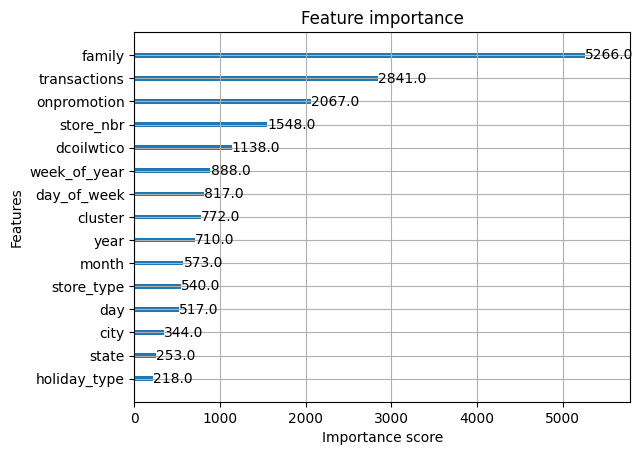

In [209]:
from xgboost import plot_importance

plt.figure(figsize=(12,8))

plot_importance(
    best_model,
    max_num_features=15
)

plt.show()